In [ ]:
!pip install skyfield


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.0/367.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 234.5/234.5 kB 13.6 MB/s eta 0:00:00


In [ ]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 57.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.5/184.5 kB 16.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
!pip install 'shimmy>=2.0'

In [ ]:
import gym
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from gym import spaces
from scipy.spatial import distance
import random
import datetime
from datetime import timezone
from datetime import datetime

helper functions outside class

Helper Functions ----------------------------------------------------------

In [ ]:
import numpy as np
from datetime import datetime, timezone
def satellite_coverage_check(r1, r2, Re=6371, threshold=500):
        r1, r2 = np.array(r1), np.array(r2)
        d = np.linalg.norm(r1 - r2)
        d_min = np.linalg.norm(np.cross(r1, r2)) / d
        return d_min > Re - threshold  # relxing the constraint

def is_on_earth(position, epsilon=10):
    R_E = 6371  #
    distance_from_center = np.linalg.norm(position)
    return abs(distance_from_center - R_E) <= epsilon
def julian_date(utc_time):
    """Convert UTC time to Julian Date."""
    unix_epoch = datetime(1970, 1, 1, 0, 0, 0, tzinfo=timezone.utc)
    delta_seconds = (utc_time - unix_epoch).total_seconds()
    julian_date = 2440587.5 + delta_seconds / 86400.0
    return julian_date

def gst_from_julian(julian_date):
    """Compute Greenwich Sidereal Time from Julian Date."""
    T = (julian_date - 2451545.0) / 36525.0
    # Compute GST in degrees, modulo 360 to stay within bounds
    GST = 280.46061837 + 360.98564736629 * (julian_date - 2451545.0) + 0.000387933 * T**2 - (T**3 / 38710000.0)
    GST = GST % 360.0  # Ensure GST is within [0, 360] degrees
    return np.radians(GST)



def geodetic_to_eci(lat_deg, lon_deg, altitude_km=0, utc_time=None):

      if utc_time is None:
        utc_time = datetime.utcnow().replace(tzinfo=timezone.utc)

      lat = np.radians(lat_deg)
      lon = np.radians(lon_deg)

      R_E = 6378.137

    # Compute the Julian Date from the given UTC time
      jd = julian_date(utc_time)

      gst = gst_from_julian(jd)

      lon_eci = lon + gst  # Longitude in the inertial frame (ECI)

      x = (R_E + altitude_km) * np.cos(lat) * np.cos(lon_eci)
      y = (R_E + altitude_km) * np.cos(lat) * np.sin(lon_eci)
      z = (R_E + altitude_km) * np.sin(lat)

      return x, y, z



def is_on_earth(position, epsilon=1e-3):#to check wether the current node is a sallite or a ground point while routing
    R_E = 6371
    distance_from_center = np.linalg.norm(position)
    return abs(distance_from_center - R_E) >= epsilon


In [ ]:

import heapq
import numpy as np
from math import radians, sin, cos, sqrt, atan2

def great_circle_distance(pos1, pos2, R_E=6371):

     #the greatcircle dist
    lat1 = np.arcsin(pos1[2] / np.linalg.norm(pos1))
    lon1 = np.arctan2(pos1[1], pos1[0])
    lat2 = np.arcsin(pos2[2] / np.linalg.norm(pos2))
    lon2 = np.arctan2(pos2[1], pos2[0])

    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R_E * c
def a_star_routing(source, target, satellite_positions, R_E=6371.8):

    # reverse lookup
    position_to_index = {tuple(v): k for k, v in satellite_positions.items()}

    if tuple(source) not in position_to_index or tuple(target) not in position_to_index:
        raise ValueError("src or tgt position not in satellite_positions.")

    open_set = []
    heapq.heappush(open_set, (0, source))  # (f_cost, current_node)

    g_cost = {tuple(pos): float('inf') for pos in satellite_positions.values()}
    g_cost[tuple(source)] = 0

    came_from = {}
    visited_sats = set()

    def edge_cost(current, neighbor):

        return great_circle_distance(np.array(current), np.array(neighbor))

    def heuristic_cost_estimate(current, goal, method="delay"):

        if method == "delay":
            return great_circle_distance(np.array(current), np.array(goal))

    def get_neighbors(current, satellite_positions, max_range=2000):

        neighbors = []
        current_pos = np.array(current)
        for pos in satellite_positions.values():
            if satellite_coverage_check(current, pos):
                neighbors.append(tuple(pos))
        return neighbors
    def reconstruct_path(came_from, current):

        path = [current]
        while current in came_from:
            current = came_from[current]
            path.insert(0, current)

        hop_distances = [edge_cost(path[i], path[i + 1]) for i in range(len(path) - 1)]
        total_distance = sum(hop_distances)

        print("hop dists:", hop_distances)
        return [position_to_index[tuple(p)] for p in path], total_distance

    while open_set:
        _, current = heapq.heappop(open_set)
        visited_sats.add(position_to_index[tuple(current)])

        if np.array_equal(current, target):
            path_indices, distance = reconstruct_path(came_from, tuple(current))
            if distance > R_E:
                print(" total  dist is  > re : the path involves multiple hops.")
            return distance, list(visited_sats), path_indices

        for neighbor in get_neighbors(current, satellite_positions):
            if tuple(neighbor) in visited_sats:
                continue
            tentative_g_cost = g_cost[tuple(current)] + edge_cost(current, neighbor)

            if tentative_g_cost < g_cost[tuple(neighbor)]:
                g_cost[tuple(neighbor)] = tentative_g_cost
                f_cost = tentative_g_cost + heuristic_cost_estimate(neighbor, target)
                heapq.heappush(open_set, (f_cost, neighbor))
                came_from[tuple(neighbor)] = tuple(current)

    return float('inf'), list(visited_sats), []  # no valid path

In [ ]:
import numpy as np


Re = 6371
altitude = 550  #

berlin_lat, berlin_lon = 52.52, 13.405
cape_town_lat, cape_town_lon = -33.9249, 18.4241




def line_of_sight(point1, point2, R_E=6371.8):

    point1 = np.array(point1)
    point2 = np.array(point2)

    point1_to_point2 = point2 - point1

    distance = np.linalg.norm(point1_to_point2)

    point1_distance = np.linalg.norm(point1)
    point2_distance = np.linalg.norm(point2)

    angle = np.arccos(np.dot(point1_to_point2, point1) / (distance * point1_distance))

    if angle < np.pi / 2 and distance > np.sqrt(point1_distance**2 - R_E**2) + np.sqrt(point2_distance**2 - R_E**2):
        return True  # los
    else:
        return False  # Earth blocks the los


berlin_pos = geodetic_to_eci(berlin_lat, berlin_lon, 0)
cape_town_pos = geodetic_to_eci(cape_town_lat, cape_town_lon, 0)
"""

num_satellites = 100
satellites_in_los_berlin = []
satellites_in_los_cape_town = []
satellites_eci = dict()
print(cape_town_pos)

for i in range(num_satellites):
    sat_lat = np.random.uniform(-90, 90)
    sat_lon = np.random.uniform(-180, 180)
    satellite_pos = geodetic_to_eci(sat_lat, sat_lon, altitude)
    satellites_eci[i]=satellite_pos
    if line_of_sight(satellite_pos, berlin_pos):
        satellites_in_los_berlin.append((sat_lat, sat_lon, altitude))

    if line_of_sight(satellite_pos, cape_town_pos):
        satellites_in_los_cape_town.append((sat_lat, sat_lon, altitude))
"""


num_satellites = 50
satellites_in_los_berlin = {}
satellites_in_los_cape_town = {}
satellites_eci = {}
#adding ground pomts to the dict eci q
satellites_eci[0]=berlin_pos
satellites_eci[-1]=cape_town_pos

for i in range(1,num_satellites-1):
    sat_lat = np.random.uniform(-90, 90)
    sat_lon = np.random.uniform(-180, 180)
    satellite_pos = geodetic_to_eci(sat_lat, sat_lon, altitude)
    satellites_eci[i] = satellite_pos  # Add sat to dict

    if line_of_sight(satellite_pos, berlin_pos):
        satellites_in_los_berlin[i]=(sat_lat, sat_lon, altitude)

    if line_of_sight(satellite_pos, cape_town_pos):
        satellites_in_los_cape_town[i]=(sat_lat, sat_lon, altitude)


source = berlin_pos
target = cape_town_pos


distance, visited_sats, path = a_star_routing(source, target, satellites_eci)


print(f"Distance: {distance} km")
print(f"Visited Satellites: {visited_sats}")
print(f"Path indicies: {path}")
for idx in path:

  print(f"Path (ECI coordinates): {satellites_eci[idx]}")

hop dists: [np.float64(3864.4802093801236), np.float64(5825.98759066937)]
 total  dist is  > re : the path involves multiple hops.
Distance: 9690.467800049493 km
Visited Satellites: [0, 35, -1]
Path indicies: [0, 35, -1]
Path (ECI coordinates): (np.float64(3876.0666883136505), np.float64(-195.56747529392428), np.float64(5061.47132572352))
Path (ECI coordinates): (np.float64(6545.655993958817), np.float64(618.6884845016305), np.float64(2184.191946387742))
Path (ECI coordinates): (np.float64(5288.7265157132715), np.float64(196.76621119682602), np.float64(-3559.6750541154174))


<ipython-input-5-4cd2eaaaad05>:6: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d


In [ ]:
print (path)

[0, 35, -1]


In [ ]:
print(satellites_eci)

{0: (np.float64(3876.0666883136505), np.float64(-195.56747529392428), np.float64(5061.47132572352)), -1: (np.float64(5288.7265157132715), np.float64(196.76621119682602), np.float64(-3559.6750541154174)), 1: (np.float64(4054.9586297920737), np.float64(-659.5039265590786), np.float64(-5578.659997911411)), 2: (np.float64(4673.602602117742), np.float64(3145.9259238067702), np.float64(-4032.328246828101)), 3: (np.float64(4339.2800726686855), np.float64(5400.868205771566), np.float64(-18.798021046662896)), 4: (np.float64(-4186.376949288412), np.float64(-2801.8258716280297), np.float64(-4756.374892111794)), 5: (np.float64(5566.9865206584245), np.float64(3821.7267875650978), np.float64(1549.8863606031796)), 6: (np.float64(932.669964848414), np.float64(1651.1689074375815), np.float64(-6663.546373107194)), 7: (np.float64(-4829.460335958169), np.float64(4255.6665698531515), np.float64(-2562.1665052080666)), 8: (np.float64(-2401.292441763825), np.float64(6498.40121875554), np.float64(-60.485535241

helper functions --------------------------

under trial not integrated yet

a trial functions ----------------------------






In [ ]:
import numpy as np

def delta_walker_constellation(P, S, altitude, inclination, R_E=6371.8):

    satellites = {}
    index = 0

    inclination_rad = np.radians(inclination)

    semi_major_axis = R_E + altitude
    delta_omega = 360 / P  #
    delta_nu = 360 / S     #

    for plane in range(P):
        omega = plane * delta_omega
        for sat in range(S):
            nu = sat * delta_nu
            x = semi_major_axis * (np.cos(np.radians(omega)) * np.cos(np.radians(nu)) -
                                   np.sin(np.radians(omega)) * np.sin(np.radians(nu)) * np.cos(inclination_rad))
            y = semi_major_axis * (np.sin(np.radians(omega)) * np.cos(np.radians(nu)) +
                                   np.cos(np.radians(omega)) * np.sin(np.radians(nu)) * np.cos(inclination_rad))
            z = semi_major_axis * (np.sin(np.radians(nu)) * np.sin(inclination_rad))
            satellites[index] = np.array([x, y, z])
            index += 1

    return satellites

In [ ]:
P = 5  # planes
S = 6  # sats per plane
altitude = 800
inclination = 53
F = 1  # phasing


In [ ]:
satellites_eci_DW = delta_walker_constellation(P, S, altitude, inclination)
berlin_pos = geodetic_to_eci(52.52, 13.405, 0)
cape_town_pos = geodetic_to_eci(-33.9249, 18.4241, 0)

satellites_eci_DW[-1] = cape_town_pos  # Cape Town
satellites_eci_DW[0] = berlin_pos      # Berlin


In [ ]:
berlin_pos, cape_town_pos

((np.float64(3876.067577036007),
  np.float64(-195.54986038810884),
  np.float64(5061.47132572352)),
 (np.float64(5288.725668791614),
  np.float64(196.78897362934146),
  np.float64(-3559.6750541154174)))

In [ ]:
satellites_eci_DW


{0: (np.float64(3876.067577036007),
  np.float64(-195.54986038810884),
  np.float64(5061.47132572352)),
 1: array([3585.9       , 3737.84963251, 4960.29399882]),
 2: array([-3585.9       ,  3737.84963251,  4960.29399882]),
 3: array([-7.17180000e+03,  5.28569436e-13,  7.01435332e-13]),
 4: array([-3585.9       , -3737.84963251, -4960.29399882]),
 5: array([ 3585.9       , -3737.84963251, -4960.29399882]),
 6: array([2216.20808026, 6820.78712357,    0.        ]),
 7: array([-2446.8022098 ,  4565.45262065,  4960.29399882]),
 8: array([-4663.01029006, -2255.33450292,  4960.29399882]),
 9: array([-2.21620808e+03, -6.82078712e+03,  7.01435332e-13]),
 10: array([ 2446.8022098 , -4565.45262065, -4960.29399882]),
 11: array([ 4663.01029006,  2255.33450292, -4960.29399882]),
 12: array([-5802.10808026,  4215.47827239,     0.        ]),
 13: array([-5098.10692941,  -916.24473892,  4960.29399882]),
 14: array([  704.00115085, -5131.72301132,  4960.29399882]),
 15: array([ 5.80210808e+03, -4.21547

In [ ]:
source = berlin_pos
target = cape_town_pos

distance, visited_sats, path_astar = a_star_routing(source, target, satellites_eci_DW)

print(f"Distance: {distance} km")
print(f"Visited Satellites: {visited_sats}")
print(f"Path indices: {path_astar}")
for idx in path_astar:
    print(f"Path (ECI coordinates): {satellites_eci_DW[idx]}")

hop dists: [np.float64(1947.7866810823823), np.float64(4969.914010924888), np.float64(5476.866778113119)]
 total  dist is  > re : the path involves multiple hops.
Distance: 12394.56747012039 km
Visited Satellites: [0, 15, 20, 25, -1]
Path indices: [0, 25, 15, -1]
Path (ECI coordinates): (np.float64(3876.067577036007), np.float64(-195.54986038810884), np.float64(5061.47132572352))
Path (ECI coordinates): [ 4663.01029006 -2255.33450292  4960.29399882]
Path (ECI coordinates): [ 5.80210808e+03 -4.21547827e+03  7.01435332e-13]
Path (ECI coordinates): (np.float64(5288.725668791614), np.float64(196.78897362934146), np.float64(-3559.6750541154174))


<ipython-input-5-4cd2eaaaad05>:6: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d


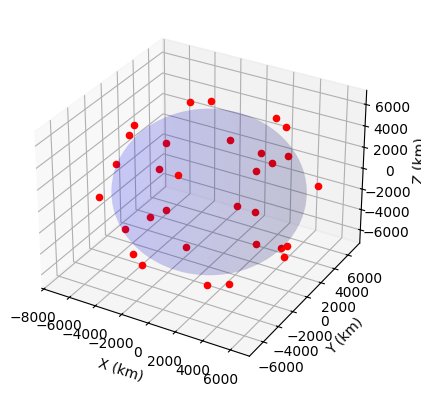

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_constellation(satellites_eci, R_E=6371.8):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot the Earth
    u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:50j]
    x = R_E * np.cos(u) * np.sin(v)
    y = R_E * np.sin(u) * np.sin(v)
    z = R_E * np.cos(v)
    ax.plot_surface(x, y, z, color='blue', alpha=0.1)

    # Plot the satellites
    for pos in satellites_eci.values():
        ax.scatter(pos[0], pos[1], pos[2], color='red')

    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zlabel('Z (km)')
    plt.show()

plot_constellation(satellites_eci_DW)

<ipython-input-17-a037be1426b2>:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


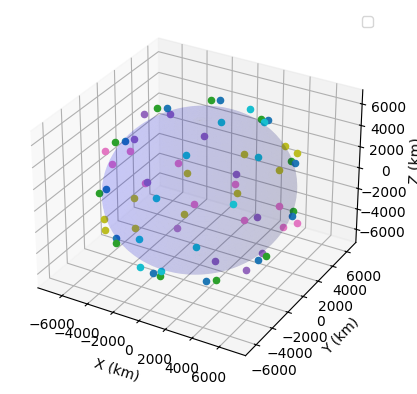

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def plot_constellation(satellites_eci, P, R_E=6371.8):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    # Plot the Earth
    u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:50j]
    x = R_E * np.cos(u) * np.sin(v)
    y = R_E * np.sin(u) * np.sin(v)
    z = R_E * np.cos(v)
    ax.plot_surface(x, y, z, color='blue', alpha=0.1)

    # Define a color map for the planes
    colors = plt.cm.tab10(np.linspace(0, 1, P))  # 10 distinct colors

    # Plot the satellites with colors based on their plane
    for idx, pos in satellites_eci.items():
        plane = idx // (len(satellites_eci) // P)  # Determine the plane of the satellite
        ax.scatter(pos[0], pos[1], pos[2], color=colors[plane])

    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zlabel('Z (km)')
    plt.legend()
    plt.show()

# Example usage
P = 6  # Number of planes
satellites_eci = delta_walker_constellation(P, 11, 550, 53)  # Generate constellation
plot_constellation(satellites_eci, P)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_constellation_with_route(satellites_eci, path_indices, start,end,R_E=6371):
    pos_berlin=berlin_pos
    pos_capetown=cape_town_pos
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Plot the Earth
    u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:50j]
    x = R_E * np.cos(u) * np.sin(v)
    y = R_E * np.sin(u) * np.sin(v)
    z = R_E * np.cos(v)
    ax.plot_surface(x, y, z, color='blue', alpha=0.1)

    # Plot all satellites
    for idx, pos in satellites_eci.items():
        if idx in path_indices:
            # Highlight satellites in the optimal route
            ax.scatter(pos[0], pos[1], pos[2], color='red', s=100, label='Optimal point' if idx == path_indices[0] else "")
        else:
            # Plot other satellites
            ax.scatter(pos[0], pos[1], pos[2], color='gray', s=50, alpha=0.5)

    # Plot the optimal route
    route_positions = [satellites_eci[idx] for idx in path_indices]
    route_x = [pos[0] for pos in route_positions]
    route_y = [pos[1] for pos in route_positions]
    route_z = [pos[2] for pos in route_positions]
    ax.plot(route_x, route_y, route_z, color='green', marker='o', markersize=8, label='Optimal Route')
    #------------------------berlin capetown
    ax.scatter(start[0],start[1],start[2], color='yellow',s=50 ,marker='*',  label='start')

    ax.scatter(end[0],end[1],end[2], color='black',s=50, marker='*', label='end ')

    # Add labels and legend
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zlabel('Z (km)')
    ax.set_title('Satellite Constellation with Optimal Route')
    plt.legend()
    plt.show()

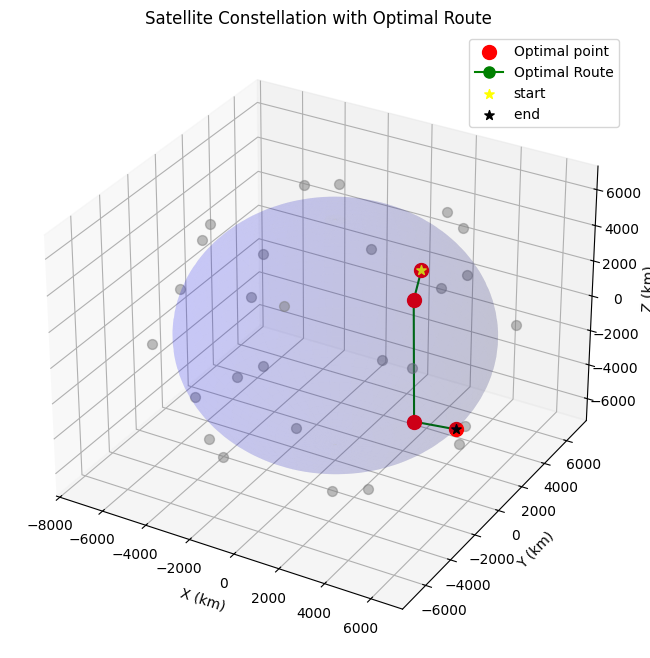

In [ ]:
start = berlin_pos
end = cape_town_pos
plot_constellation_with_route(satellites_eci_DW, path_astar,start,end)


In [ ]:
P2 = 4  # planes
S2 = 4  # sats per plane
altitude = 900
inclination = 55
F = 1  # phasing


In [ ]:
satellites_eci_DW2 = delta_walker_constellation(P2, S2, altitude, inclination)


satellites_eci_DW2[-1] = cape_town_pos  # Cape Town
satellites_eci_DW2[0] = berlin_pos      # Berlin


In [ ]:
satellites_eci_DW2


{0: (np.float64(3876.067577036007),
  np.float64(-195.54986038810884),
  np.float64(5061.47132572352)),
 1: array([4.45269330e-13, 4.17093313e+03, 5.95670984e+03]),
 2: array([-7.27180000e+03,  5.10791991e-13,  7.29486563e-13]),
 3: array([-1.33580799e-12, -4.17093313e+03, -5.95670984e+03]),
 4: array([4.4526933e-13, 7.2718000e+03, 0.0000000e+00]),
 5: array([-4.17093313e+03,  7.00665325e-13,  5.95670984e+03]),
 6: array([-9.56061320e-13, -7.27180000e+03,  7.29486563e-13]),
 7: array([ 4.17093313e+03, -1.59120398e-12, -5.95670984e+03]),
 8: array([-7.27180000e+03,  8.90538659e-13,  0.00000000e+00]),
 9: array([-9.56061320e-13, -4.17093313e+03,  5.95670984e+03]),
 10: array([ 7.27180000e+03, -1.40133065e-12,  7.29486563e-13]),
 11: array([ 1.84659998e-12,  4.17093313e+03, -5.95670984e+03]),
 12: array([-1.33580799e-12, -7.27180000e+03,  0.00000000e+00]),
 13: array([ 4.17093313e+03, -1.21145732e-12,  5.95670984e+03]),
 14: array([1.84659998e-12, 7.27180000e+03, 7.29486563e-13]),
 15: ar

In [ ]:
source = berlin_pos
target = cape_town_pos

distance2, visited_sats2, path_astar2 = a_star_routing(source, target, satellites_eci_DW2)

print(f"Distance: {distance} km")
print(f"Visited Satellites: {visited_sats2}")
print(f"Path indices: {path_astar2}")
for idx in path_astar2:
    print(f"Path (ECI coordinates): {satellites_eci_DW2[idx]}")

hop dists: [np.float64(5846.160327926859), np.float64(3778.8221641833643)]
 total  dist is  > re : the path involves multiple hops.
Distance: 12394.56747012039 km
Visited Satellites: [0, 10, -1]
Path indices: [0, 10, -1]
Path (ECI coordinates): (np.float64(3876.067577036007), np.float64(-195.54986038810884), np.float64(5061.47132572352))
Path (ECI coordinates): [ 7.27180000e+03 -1.40133065e-12  7.29486563e-13]
Path (ECI coordinates): (np.float64(5288.725668791614), np.float64(196.78897362934146), np.float64(-3559.6750541154174))


<ipython-input-5-4cd2eaaaad05>:6: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d


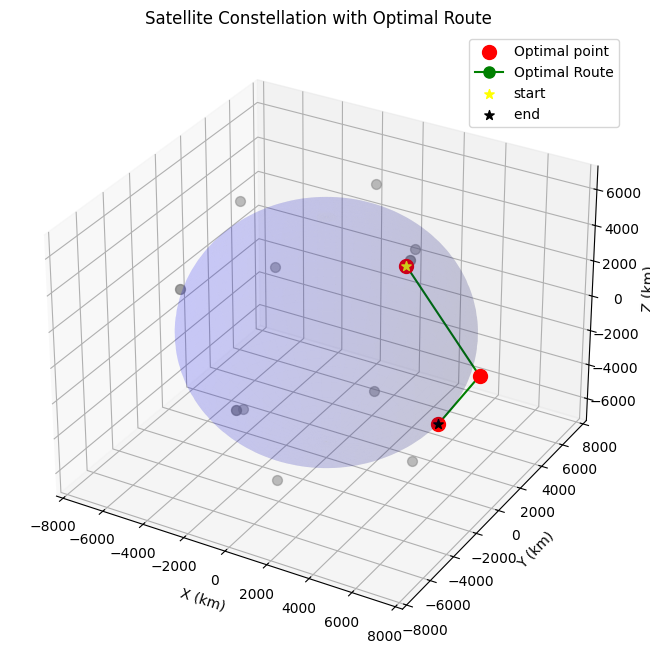

In [ ]:
plot_constellation_with_route(satellites_eci_DW2, path_astar2, start,end,R_E=6371)

In [ ]:
Re=6371
new_york_pos = geodetic_to_eci(40.7128, -74.0060, 0)
tokyo_pos = geodetic_to_eci(35.6762, 139.6503, 0)
sydney_pos = geodetic_to_eci(-33.8688, 151.2093, 0)
moscow_pos = geodetic_to_eci(55.7558, 37.6173, 0)
wellington_pos = geodetic_to_eci(-41.2865, 174.7762, 0)  #

alert_pos = geodetic_to_eci(82.5018, -62.3481, 0)  # Alert, Nunavut
south_pole_pos = geodetic_to_eci(-90, 0, 0)

In [ ]:



# Generate the Delta Walker constellation
satellites_eci_DW_a = delta_walker_constellation(P=2, S=2, altitude=400, inclination=53)

# Add ground stations to the dictionary
satellites_eci_DW_a[0] = cape_town_pos  #)
satellites_eci_DW_a[1] = berlin_pos
satellites_eci_DW_a[2] = new_york_pos
satellites_eci_DW_a[3] = tokyo_pos
satellites_eci_DW_a[4] = sydney_pos
satellites_eci_DW_a[5] = moscow_pos
satellites_eci_DW_a[6] = wellington_pos
satellites_eci_DW_a[7] = alert_pos
satellites_eci_DW_a[8] = south_pole_pos


start_end_pairs = [
    (new_york_pos, tokyo_pos),    #
    (sydney_pos, moscow_pos),
    (berlin_pos, new_york_pos),
    (cape_town_pos, sydney_pos),
    (berlin_pos, wellington_pos),
    (alert_pos,south_pole_pos)
]


In [ ]:
results = []  # List to store results

for start, end in start_end_pairs:
    print(f"Routing from {start} to {end}")
    distance, visited_sats, path = a_star_routing(start, end, satellites_eci_DW_a)
    if distance == float('inf'):
      print("No los comeback later")
    else:
      print(f"Distance: {distance} km")
      print(f"Path indices: {path}")

    # Store results in a dictionary
    result = {
        "start": start,
        "end": end,
        "distance": distance,
        "visited_sats": visited_sats,
        "path": path
    }
    results.append(result)  # Add the result to the list

    # Print the results
    print(f"Distance: {distance} km")
    print(f"Visited Satellites: {visited_sats}")
    print(f"Path indices: {path}")
    for idx in path:
        print(f"Path (ECI coordinates): {satellites_eci_DW_a[idx]}")
    print("\n")

Routing from (np.float64(-20.254901384019877), np.float64(-4834.512941602951), np.float64(4160.253110955209)) to (np.float64(-2853.336722519699), np.float64(4324.642391858987), np.float64(3719.753932886652))
No los comeback later
Distance: inf km
Visited Satellites: [1, 2, 5, 7]
Path indices: []


Routing from (np.float64(-3743.126718974314), np.float64(3746.3615315832612), np.float64(-3554.4914166646554)) to (np.float64(3342.0473659104955), np.float64(1308.607329388675), np.float64(5272.466012431939))
No los comeback later
Distance: inf km
Visited Satellites: [4, 6]
Path indices: []


Routing from (np.float64(3876.067577036007), np.float64(-195.54986038810884), np.float64(5061.47132572352)) to (np.float64(-20.254901384019877), np.float64(-4834.512941602951), np.float64(4160.253110955209))
hop dists: [np.float64(4031.2879169823664), np.float64(4666.19907963137)]
 total  dist is  > re : the path involves multiple hops.
Distance: 8697.486996613738 km
Path indices: [1, 7, 2]
Distance: 869

<ipython-input-5-4cd2eaaaad05>:6: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d


In [ ]:
results[5]["distance"]-Re

inf

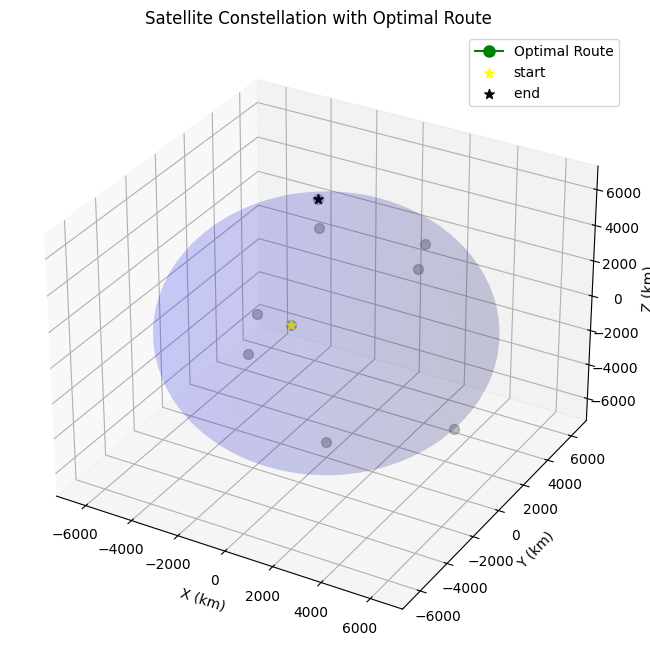

In [ ]:
plot_constellation_with_route(satellites_eci_DW_a, results[0]["path"], results[1]["start"],results[0]["end"],R_E=6371)


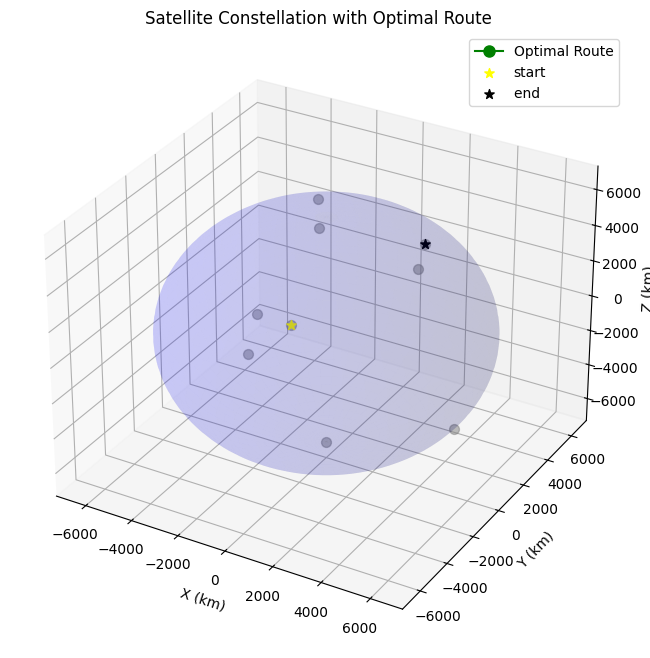

In [ ]:
plot_constellation_with_route(satellites_eci_DW_a, results[1]["path"], results[1]["start"],results[1]["end"],R_E=6371)


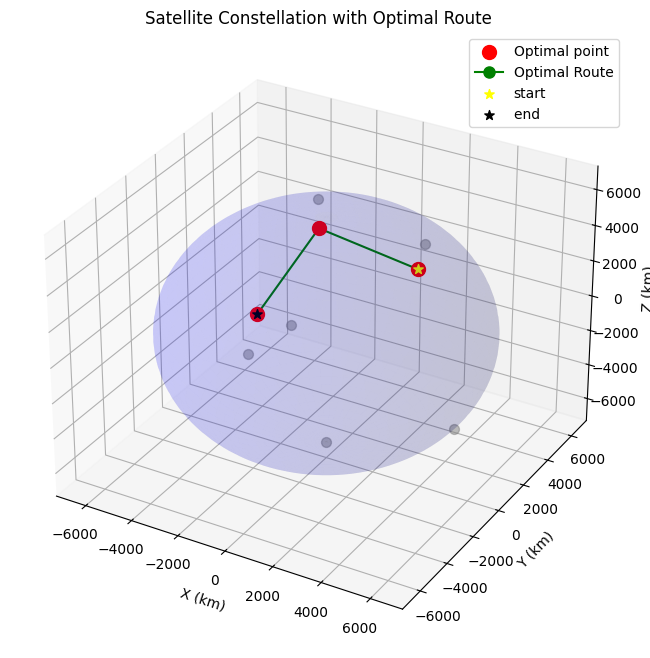

In [ ]:
plot_constellation_with_route(satellites_eci_DW_a, results[2]["path"], results[2]["start"],results[2]["end"],R_E=6371)

In [ ]:
P3 = 2  # planes
S3 = 4  # sats per plane
altitude = 700
inclination = 45
F = 1  # phasing

berlin_pos = geodetic_to_eci(52.52, 13.405, 0)  #


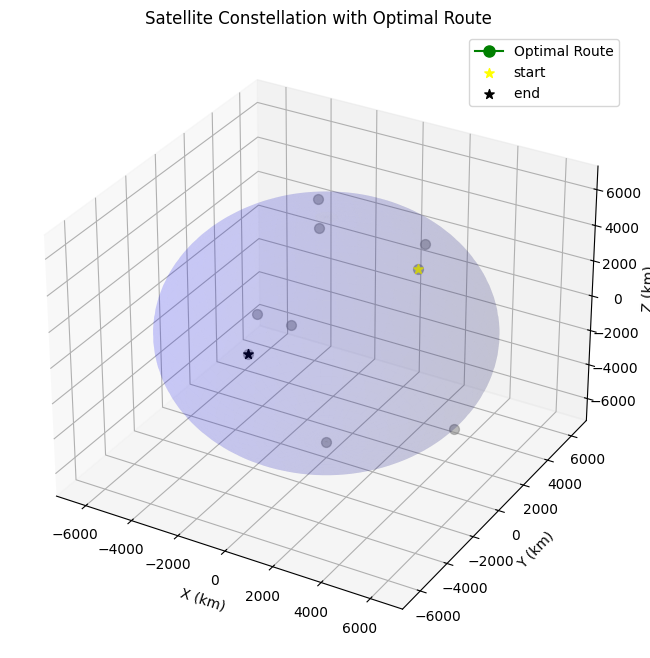

In [ ]:
plot_constellation_with_route(satellites_eci_DW_a, results[4]["path"], results[4]["start"],results[4]["end"],R_E=6371)

In [ ]:
results[4]["distance"]

inf

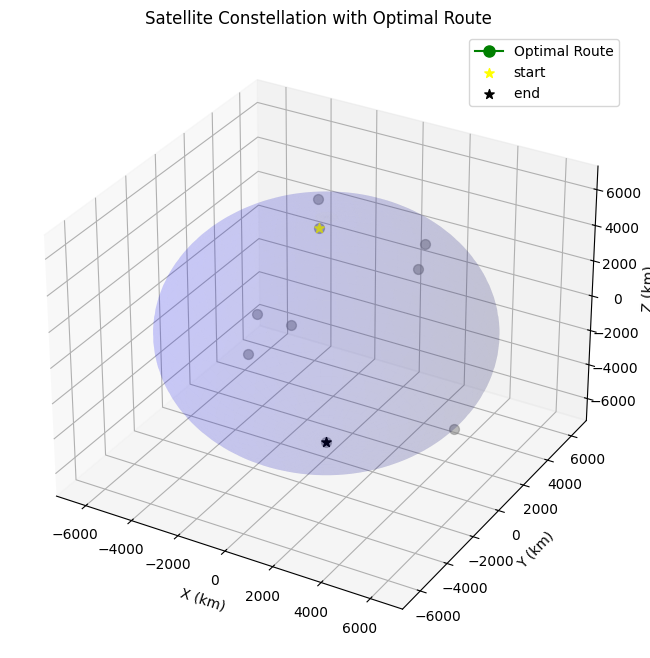

In [ ]:
plot_constellation_with_route(satellites_eci_DW_a, results[5]["path"], results[5]["start"],results[5]["end"],R_E=6371)

In [ ]:
h

/usr/local/lib/python3.11/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/usr/local/lib/python3.11/dist-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


Observation Shape: (4,)
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


<ipython-input-36-92607b75f76d>:298: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d
<ipython-input-36-92607b75f76d>:306: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d


Streaming output truncated to the last 5000 lines.
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9625.912731525299
reward in step 6.956767940354994
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9625.912731525299
reward in step 6.956767940354994
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9625.912731525299
reward in step 6.956767940354994
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9625.912731525299
reward in step 6.956767940354994
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9625.912731525299
reward in step 6.956767940354994
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9625.912731525299
reward in step 6.956767940354994
Total distance is greater than Earth's radius: the path invol

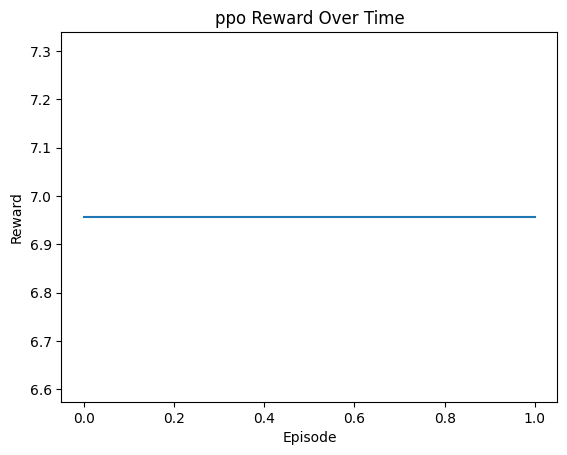

In [ ]:
import gym
import numpy as np
import heapq
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from stable_baselines3 import A2C,PPO

class SatelliteRoutingEnv(gym.Env):
    def __init__(self):
        super(SatelliteRoutingEnv, self).__init__()
        self.R_E = 6371
        self.num_satellites = 3
        self.state_space_var = 3  # lat, long, h
        self.P = 5
        self.inclination = 60
        self.S = 8
        self.altitude = 900
        self.satellites_eci = self.delta_walker_constellation(self.P, self.S, self.altitude, self.inclination)
        self.current_time = datetime.utcnow()
        self.A = self.geodetic_to_eci(52.52, 13.41)  # berl
        self.B = self.geodetic_to_eci(-33.92, 18.42)  # Cape

        self.A_ecef=self.geodetic_to_ecef(52.52, 13.41)
        self.B_ecef=self.geodetic_to_ecef(-33.92, 18.42)
        self.elevation_threshold = 5.0  # deg

       ##################################################################
        self.satellites_eci[1] = self.A
        self.satellites_eci[0] = self.B

        # act space: multi-disc actions
        self.delta_height_range = [-100, 0, 100]
        self.delta_angle_range = [-5, 0, 5]

        # stat space: [P, S, altitude, icl]
        self.observation_space = spaces.Box(
            low=np.array([4, 6, 600, 60]),
            high=np.array([6, 8, 1000, 90]),
            dtype=np.float32
        )

        self.state = self._generate_random_state()
        self.action_space = spaces.MultiDiscrete([
            3,  # delta P: [-1, 0, 1]
            3,  # delta in S: [-1, 0, 1]
            3,  #  delta h: [-50, 0, 50]
            3   # delta inc: [-5, 0, 5] deg
        ])

    def _generate_random_state(self):
        return np.array([
            self.P,
            self.S,
            self.altitude,
            self.inclination
        ], dtype=np.float32)

    def reset(self):
        # reset state to a rand DWconfiguration
        self.state = self._generate_random_state()

        # reg the constellation with the new parameters
        self.satellites_eci = self.delta_walker_constellation(
            int(self.state[0]),  # P
            int(self.state[1]),  # S
            self.state[2],       # alt
            self.state[3]        # inc
        )
        self.satellites_eci[1] = self.B
        self.satellites_eci[0] = self.A

        return np.array(self.state, dtype=np.float32)
    def compute_reward(self, distance, num_visited, path_length,has_los_to_1,has_los):
        #  reward function
        #coverage = self.calculate_coverage(self.state[2], int(self.state[0] * self.state[1]))
        latency = distance / 299792.458
        los_1_penalty = 1 if not has_los_to_1 else 0
        los_2_penalty = 1 if not has_los else 0

        print("los_1_penalty",los_1_penalty) if  has_los_to_1 else None

        reward =  (latency * 10) - (path_length * 5) - (los_1_penalty * 10) - (los_2_penalty * 10)

        return reward
    def compute_reward2(self, state,distance, path):

        reward = 0
        valid_los_links = 0
        path_exists = len(path) > 0
        loop_penalty = 0

        if path_exists:
        # LoS link ratio
          total_hops = len(path)-1
          for i in range(total_hops):
            sat1 = self.satellites_eci[path[i]]
            sat2 = self.satellites_eci[path[i+1]]
            if self.satellite_coverage_check(sat1, sat2):
                valid_los_links += 1
            #chk for loops
            if i > 0 and path[i] == path[i-1]:
                loop_penalty -= 2.0

          los_ratio = valid_los_links / total_hops if total_hops > 0 else 0

          distance_km = distance
          latency = distance_km / 299792.458 * 1000
          hop_count = len(path) - 1

          reward += (
            5.0 * los_ratio +                  # max LoS link
            2.0 * (1 / (hop_count + 1e-6)) +   # min hops
            1.5 * (1 / (latency + 1e-6)) +     # min latency
            0.5 * (1 / (distance_km + 1e-6))   # min  dis
          )
        else:
         #  penalty for no path
         reward -= 10.0

        P, S, altitude, inclination = self.state
        reward += (
        0.1 * (P * S) / 100 +          # +ve reward sat dens ---planes
        0.05 * (altitude / 1000)  )    # +ve reward sat high h
        #0.02 * abs(inclination - 53)


        reward += loop_penalty

        return reward
    def step(self, action):
        # apply  action to  DW parms
        delta_P, delta_S, delta_alt, delta_inc = action - 1  # Convert [0,1,2] to [-1,0,1]

        new_P = np.clip(self.state[0] + delta_P, 4, 10)
        new_S = np.clip(self.state[1] + delta_S, 6, 12)
        new_altitude = np.clip(self.state[2] + delta_alt * 50, 500, 1000)
        new_inclination = np.clip(self.state[3] + delta_inc * 5, 60, 90)

        self.state = np.array([new_P, new_S, new_altitude, new_inclination], dtype=np.float32)
        #print("self.state in step",self.state)

        #  constellation with new params
        self.satellites_eci = self.delta_walker_constellation(
            int(new_P), int(new_S), new_altitude, new_inclination
        )
        #print("self.satellites_eci in step",self.satellites_eci)
        self.satellites_eci[0] = self.B

        self.satellites_eci[1] = self.A

        #  A* f
        distance, visited_sats, path = self.a_star_routing(self.A, self.B, self.satellites_eci)
        print("distance in step",distance)

        #gs changes every step either a or b
        gs = self.B_ecef if np.random.rand() < 0.5 else self.A_ecef#


        has_los_1=self.satellite_coverage_check_all(self.satellites_eci,self.A,path, Re=6371,threshold=500)
        has_los_2=self.satellite_coverage_check_all(self.satellites_eci,self.B,path, Re=6371,threshold=500)

        #  reward
        #reward = self.compute_reward(distance, len(visited_sats), len(path),has_los_1,has_los_2)
        reward=self.compute_reward2(self.state,distance, path)
        print("reward in step",reward)

        done = False  #  termination
        return self.state, reward, done, {"distance": distance, "path_length": len(path)}



    def calculate_coverage(self, altitude, num_satellites):
        #  coverage  based on h and  # sats

        return 1 - np.exp(-num_satellites * altitude / (2 * (self.R_E + altitude)))

    def eci_to_lat_lon(self, eci_coords, R_E=6371):
        x, y, z = eci_coords
        r = np.sqrt(x**2 + y**2 + z**2)

        lat = np.arcsin(z / r)
        lat_deg = np.degrees(lat)

        lon = np.arctan2(y, x)
        lon_deg = np.degrees(lon)

        return lat_deg, lon_deg

    def delta_walker_constellation(self, P, S, altitude, inclination, R_E=6371):
        satellites = {}
        index = 0

        inclination_rad = np.radians(inclination)

        a = R_E + altitude

        delta_omega = 360 / P  # RAAN separation - planes
        delta_nu = 360 / S     # true anomaly separation - sats

        for plane in range(P):
            omega = plane * delta_omega  # RAAN curr plane
            for sat in range(S):
                nu = sat * delta_nu  # true anom

                x = a * (np.cos(np.radians(omega)) * np.cos(np.radians(nu)) -
                    np.sin(np.radians(omega)) * np.sin(np.radians(nu)) * np.cos(inclination_rad))
                y = a * (np.sin(np.radians(omega)) * np.cos(np.radians(nu)) +
                    np.cos(np.radians(omega)) * np.sin(np.radians(nu)) * np.cos(inclination_rad))
                z = a * (np.sin(np.radians(nu)) * np.sin(inclination_rad))
                satellites[index] = np.array([x, y, z])
                index += 1

        return satellites

    def a_star_routing(self, source, target, satellite_positions, R_E=6371.8):
        # A*
        position_to_index = {tuple(v): k for k, v in satellite_positions.items()}

        if tuple(source) not in position_to_index or tuple(target) not in position_to_index:
            raise ValueError("src or tgt position not in satellite_positions.")

        open_set = []
        heapq.heappush(open_set, (0, source))  # (f_cost, current_node)

        g_cost = {tuple(pos): float('inf') for pos in satellite_positions.values()}
        g_cost[tuple(source)] = 0

        came_from = {}
        visited_sats = set()

        def edge_cost(current, neighbor):
            return self.great_circle_distance(np.array(current), np.array(neighbor))

        def heuristic_cost_estimate(current, goal):
            return self.great_circle_distance(np.array(current), np.array(goal))

        def get_neighbors(current, satellite_positions):
            neighbors = []
            current_pos = np.array(current)
            for pos in satellite_positions.values():
                if self.satellite_coverage_check(current_pos, pos):
                    neighbors.append(tuple(pos))
            return neighbors

        def reconstruct_path(came_from, current):
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.insert(0, current)
            hop_distances = [edge_cost(path[i], path[i + 1]) for i in range(len(path) - 1)]
            total_distance = sum(hop_distances)
            return [position_to_index[tuple(p)] for p in path], total_distance

        while open_set:
            _, current = heapq.heappop(open_set)
            visited_sats.add(position_to_index[tuple(current)])

            if np.array_equal(current, target):
                path_indices, distance = reconstruct_path(came_from, tuple(current))
                if distance > R_E:
                    print("Total distance is greater than Earth's radius: the path involves multiple hops.")
                return distance, list(visited_sats), path_indices

            for neighbor in get_neighbors(current, satellite_positions):
                if tuple(neighbor) in visited_sats:
                    continue
                tentative_g_cost = g_cost[tuple(current)] + edge_cost(current, neighbor)

                if tentative_g_cost < g_cost[tuple(neighbor)]:
                    g_cost[tuple(neighbor)] = tentative_g_cost
                    f_cost = tentative_g_cost + heuristic_cost_estimate(neighbor, target)
                    heapq.heappush(open_set, (f_cost, neighbor))
                    came_from[tuple(neighbor)] = tuple(current)

        return float('inf'), list(visited_sats), []  # No valid path

    def great_circle_distance(self, pos1, pos2, R_E=6371.8):
        #  great-circle  between  points
        lat1 = np.arcsin(pos1[2] / np.linalg.norm(pos1))
        lon1 = np.arctan2(pos1[1], pos1[0])
        lat2 = np.arcsin(pos2[2] / np.linalg.norm(pos2))
        lon2 = np.arctan2(pos2[1], pos2[0])

        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
        c = 2 * np.arcsin(np.sqrt(a))
        return R_E * c

    def satellite_coverage_check(self,r1, r2, Re=6371, threshold=500):
        r1, r2 = np.array(r1), np.array(r2)
        d = np.linalg.norm(r1 - r2)
        d_min = np.linalg.norm(np.cross(r1, r2)) / d
        return d_min > Re - threshold  # relxing constraint

    def satellite_coverage_check_all(self,satellites_eci,gs,path, Re=6371,threshold=500):
      for idxs in path:
        sat_eci = satellites_eci[idxs]
        r1, r2 = np.array(sat_eci), np.array(gs)
        d = np.linalg.norm(r1 - r2)
        d_min = np.linalg.norm(np.cross(r1, r2)) / d
        return d_min > Re - threshold  # relxing constraint




    def geodetic_to_eci(self, lat_deg, lon_deg, altitude_km=0, utc_time=None):
        if utc_time is None:
            utc_time = datetime.utcnow().replace(tzinfo=timezone.utc)

        lat = np.radians(lat_deg)
        lon = np.radians(lon_deg)
        R_E = 6371.8

        jd = self.julian_date(utc_time)
        gst = self.gst_from_julian(jd)
        lon_eci = lon + gst  # long  (ECI)

        x = (R_E + altitude_km) * np.cos(lat) * np.cos(lon_eci)
        y = (R_E + altitude_km) * np.cos(lat) * np.sin(lon_eci)
        z = (R_E + altitude_km) * np.sin(lat)

        return x, y, z

    def julian_date(self, utc_time):

        unix_epoch = datetime(1970, 1, 1, 0, 0, 0, tzinfo=timezone.utc)
        delta_seconds = (utc_time - unix_epoch).total_seconds()
        return 2440587.5 + delta_seconds / 86400.0

    def gst_from_julian(self, julian_date):
        T = (julian_date - 2451545.0) / 36525.0
        GST = 280.46061837 + 360.98564736629 * (julian_date - 2451545.0) + 0.000387933 * T ** 2 - (T ** 3 / 38710000.0)
        GST = GST % 360.0  # Kn 0 to 360
        return np.radians(GST)
    def geodetic_to_ecef(self, lat_deg, lon_deg, alt_km=0):
        lat = np.radians(lat_deg)
        lon = np.radians(lon_deg)
        x = (self.R_E + alt_km) * np.cos(lat) * np.cos(lon)
        y = (self.R_E + alt_km) * np.cos(lat) * np.sin(lon)
        z = (self.R_E + alt_km) * np.sin(lat)
        return np.array([x, y, z])

    def gmst(self, dt):
        jd = (dt - datetime(2000, 1, 1, 12)).total_seconds() / 86400.0 + 2451545.0
        T = (jd - 2451545.0) / 36525
        gmst_deg = 280.46061837 + 360.98564736629 * (jd - 2451545) + \
                   0.000387933 * T**2 - (T**3) / 38710000
        return np.radians(gmst_deg % 360)

    def eci_to_ecef(self, r_eci, dt):

        theta = self.gmst(dt)
        rot = np.array([
            [np.cos(theta), np.sin(theta), 0],
            [-np.sin(theta), np.cos(theta), 0],
            [0, 0, 1]
        ])
        return rot @ r_eci

    def has_line_of_sight_to_gs(self, satellites_eci: dict, gs_ecef,dt: datetime) -> dict:

        #gs_ecef = self.A_ecef
        result = {}

        for sat_id, sat_eci in satellites_eci.items():
            sat_ecef = self.eci_to_ecef(sat_eci, dt)
            vec = sat_ecef - gs_ecef
            vec_norm = np.linalg.norm(vec)
            gs_norm = np.linalg.norm(gs_ecef)

            cos_theta = np.dot(vec, gs_ecef) / (vec_norm * gs_norm)
            cos_theta = np.clip(cos_theta, -1.0, 1.0)
            theta_rad = np.arccos(cos_theta)
            elevation_deg = np.degrees(np.pi / 2 - theta_rad)

            result[sat_id] = elevation_deg > self.elevation_threshold

        return result
    def has_line_of_sight_to_both_gs(self, satellites_eci: dict, dt: datetime) -> dict:

      result = {}

      for sat_id, sat_eci in satellites_eci.items():
        sat_ecef = self.eci_to_ecef(sat_eci, dt)

        #  LOS to gs  A
        vec_a = sat_ecef - self.A_ecef
        cos_theta_a = np.dot(vec_a, self.A_ecef) / (np.linalg.norm(vec_a) * np.linalg.norm(self.A_ecef))
        elevation_deg_a = np.degrees(np.pi / 2 - np.arccos(np.clip(cos_theta_a, -1.0, 1.0)))

        #  LOS to  gs B
        vec_b = sat_ecef - self.B_ecef
        cos_theta_b = np.dot(vec_b, self.B_ecef) / (np.linalg.norm(vec_b) * np.linalg.norm(self.B_ecef))
        elevation_deg_b = np.degrees(np.pi / 2 - np.arccos(np.clip(cos_theta_b, -1.0, 1.0)))

        #  LOS to both gss
        result[sat_id] = (elevation_deg_a > self.elevation_threshold) and (elevation_deg_b > self.elevation_threshold)

      return result




epochs = 0
env = SatelliteRoutingEnv()
rewards = []
obs = env.reset()
print("Observation Shape:", obs.shape)

# ppo
model = PPO("MlpPolicy", env, learning_rate=0.0001, verbose=1,gamma=0.9)
model.learn(total_timesteps=500000)
model.save("ppo_satellite_routing")

# eval
done = False
while epochs < 2:
    action, _states = model.predict(obs)
    obs, reward, done, _ = env.step(action)
    rewards.append(reward)
    epochs += 1
    print(f"Action: {action}, Reward: {reward}")

#
plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("ppo Reward Over Time")
plt.show()

<ipython-input-36-92607b75f76d>:298: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d
<ipython-input-36-92607b75f76d>:306: RuntimeWarning: invalid value encountered in scalar divide
  d_min = np.linalg.norm(np.cross(r1, r2)) / d


Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9765.267958314489
reward in step 6.387600489901777
Episode: 1, Reward: 6.387600489901777, Path Length: 3, Distance: 9765.267958314489
Total distance is greater than Earth's radius: the path involves multiple hops.


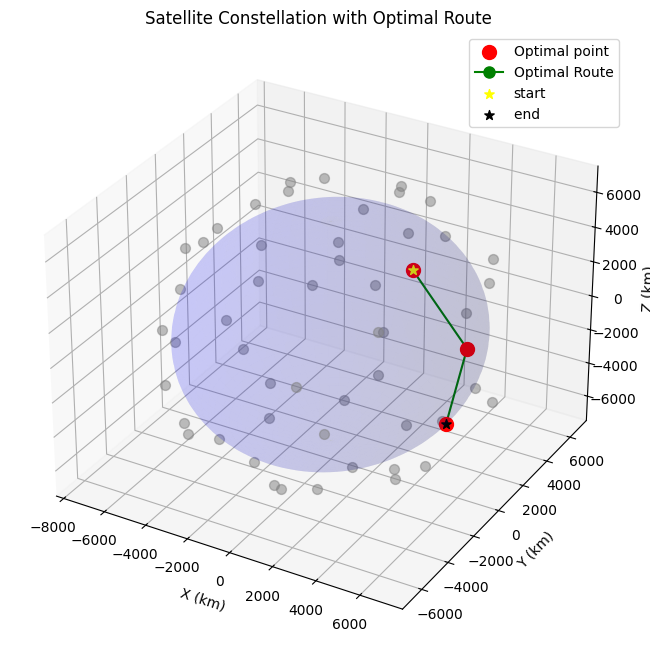

Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 10906.939526133903
reward in step 6.398774921995394
Episode: 2, Reward: 6.398774921995394, Path Length: 3, Distance: 10906.939526133903
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9686.643307322043
reward in step 6.521974686368419
Episode: 3, Reward: 6.521974686368419, Path Length: 3, Distance: 9686.643307322043
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 10413.369321087863
reward in step 6.538731295857421
Episode: 4, Reward: 6.538731295857421, Path Length: 3, Distance: 10413.369321087863
Total distance is greater than Earth's radius: the path involves multiple hops.
distance in step 9625.912731525299
reward in step 6.654267871213606
Episode: 5, Reward: 6.654267871213606, Path Length: 3, Distance: 9625.912731525299
Total distance is greater than Earth's radius: the path involves multipl

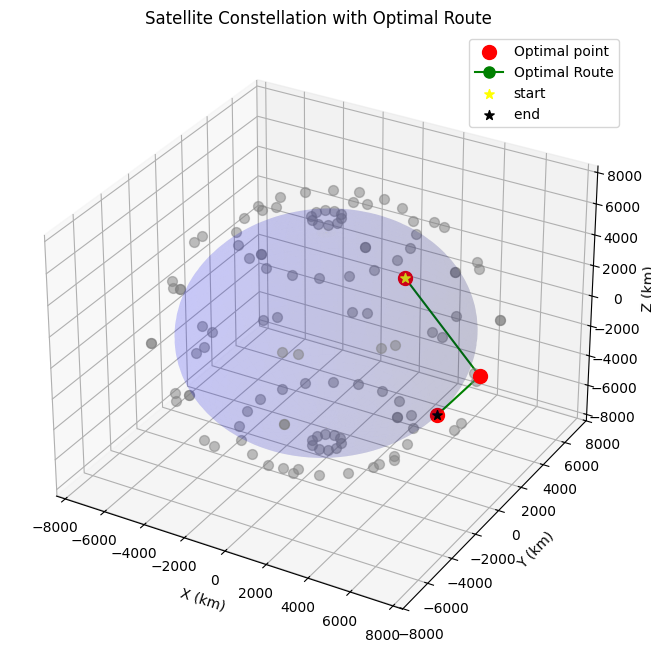

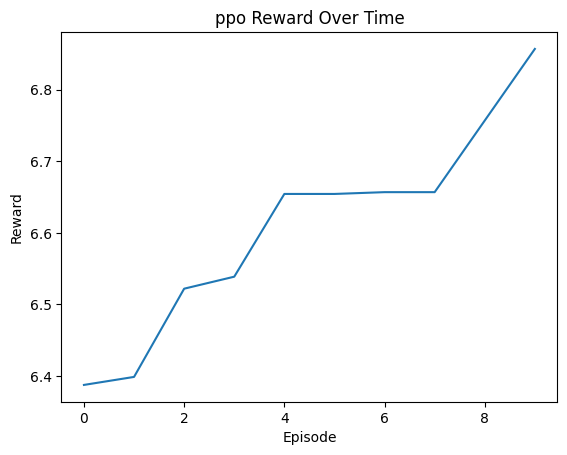

In [ ]:
# #######################
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_constellation_with_route(satellites_eci, path_indices, start,end,R_E=6371):

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    #  earth
    u, v = np.mgrid[0:2*np.pi:100j, 0:np.pi:50j]
    x = R_E * np.cos(u) * np.sin(v)
    y = R_E * np.sin(u) * np.sin(v)
    z = R_E * np.cos(v)
    ax.plot_surface(x, y, z, color='blue', alpha=0.1)

    #  all sats
    for idx, pos in satellites_eci.items():
        if idx in path_indices:
            #  sats -- optimal route
            ax.scatter(pos[0], pos[1], pos[2], color='red', s=100, label='Optimal point' if idx == path_indices[0] else "")
        else:
            #  other sats
            ax.scatter(pos[0], pos[1], pos[2], color='gray', s=50, alpha=0.5)

    #  optimal route
    route_positions = [satellites_eci[idx] for idx in path_indices]
    route_x = [pos[0] for pos in route_positions]
    route_y = [pos[1] for pos in route_positions]
    route_z = [pos[2] for pos in route_positions]
    ax.plot(route_x, route_y, route_z, color='green', marker='o', markersize=8, label='Optimal Route')
    #------------------------berlin capetown
    ax.scatter(start[0],start[1],start[2], color='yellow',s=50 ,marker='*',  label='start')

    ax.scatter(end[0],end[1],end[2], color='black',s=50, marker='*', label='end ')

    # Add labels and legend
    ax.set_xlabel('X (km)')
    ax.set_ylabel('Y (km)')
    ax.set_zlabel('Z (km)')
    ax.set_title('Satellite Constellation with Optimal Route')
    plt.legend()
    plt.show()



def plot_satellite_constellation(satellite_positions):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    x = [pos[0] for pos in satellite_positions.values()]
    y = [pos[1] for pos in satellite_positions.values()]
    z = [pos[2] for pos in satellite_positions.values()]

    ax.scatter(x, y, z, c='b', marker='o')

    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position')
    ax.set_title('Satellite Constellation')

    plt.show()



def plot_routing_paths(satellite_positions, path_indices):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    x = [pos[0] for pos in satellite_positions.values()]
    y = [pos[1] for pos in satellite_positions.values()]
    z = [pos[2] for pos in satellite_positions.values()]
    ax.scatter(x, y, z, c='b', marker='o')

    for i in range(len(path_indices) - 1):
        start = satellite_positions[path_indices[i]]
        end = satellite_positions[path_indices[i + 1]]
        ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], c='r')

    ax.set_xlabel('X Position')
    ax.set_ylabel('Y Position')
    ax.set_zlabel('Z Position')
    ax.set_title('Satellite Routing Paths')

    plt.show()










model = PPO.load("ppo_satellite_routing")

epochs = 0
rewards = []
obs = env.reset()
while epochs < 10:  # eval  10 episodes
    action, _states = model.predict(obs)
    obs, reward, done, info = env.step(action)
    rewards.append(reward)
    epochs += 1
    print(f"Episode: {epochs}, Reward: {reward}, Path Length: {info['path_length']}, Distance: {info['distance']}")


    if epochs == 1:
        #plot_satellite_constellation(env.satellites_eci)
        distance, visited_sats, path_indices = env.a_star_routing(env.A, env.B, env.satellites_eci)
        #plot_routing_paths(env.satellites_eci, path_indices)

        plot_constellation_with_route(env.satellites_eci, path_indices, env.A,env.B,R_E=6371)
    if epochs == 10:
        #plot_satellite_constellation(env.satellites_eci)
        distance, visited_sats, path_indices = env.a_star_routing(env.A, env.B, env.satellites_eci)
        #plot_routing_paths(env.satellites_eci, path_indices)

        plot_constellation_with_route(env.satellites_eci, path_indices, env.A,env.B,R_E=6371)

plt.plot(rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("ppo Reward Over Time")
plt.show()

In [ ]:
#Best Hyperparameters: learning_rate=0.0001, gamma=0.9, total_timesteps=50000, Average Reward=80.73164057670792

#Average Reward=80.47296456471369

